# MNIST dataset을 JPG 파일로 변환

Convert the original MNIST dataset into JPG format


참고 소스코드: https://github.com/teavanist/MNIST-JPG

아래 사이트에서 파일을 다운받고 압축을 푼 뒤 아래의 4개의 파일을 colab에서 왼쪽 폴더 버튼을 클릭한 후 업로드

the original MNIST dataset: https://www.kaggle.com/datasets/hojjatk/mnist-dataset






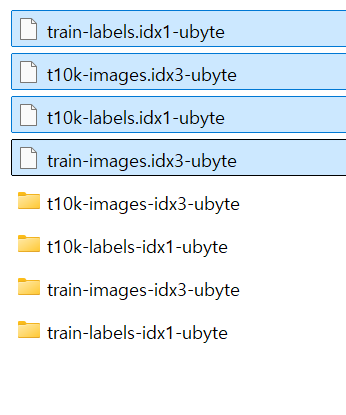

In [ ]:
import gzip
import os
import glob

# 1. 대상 폴더 경로 설정 (본인의 폴더 경로로 변경하세요)
target_folder = '/content/'

# 2. 폴더 내 모든 .gz 파일 목록 가져오기
gz_files = glob.glob(os.path.join(target_folder, '*.gz'))

if not gz_files:
    print("압축을 풀 .gz 파일이 폴더에 없습니다.")
else:
    for gz_file in gz_files:
        # 3. 원본 파일명에서 '.gz'를 제외한 출력 파일명 생성
        # 예: 'my_folder/data.txt.gz' -> 'my_folder/data.txt'
        output_file = gz_file[:-3]

        # 4. 압축 해제 및 파일 저장
        with gzip.open(gz_file, 'rb') as f_in:
            with open(output_file, 'wb') as f_out:
                f_out.write(f_in.read())

        print(f"성공: {os.path.basename(gz_file)} -> {os.path.basename(output_file)}")

    print("\n모든 파일의 압축 해제가 완료되었습니다.")

성공: train-images-idx3-ubyte.gz -> train-images-idx3-ubyte
성공: t10k-images-idx3-ubyte.gz -> t10k-images-idx3-ubyte
성공: train-labels-idx1-ubyte.gz -> train-labels-idx1-ubyte
성공: t10k-labels-idx1-ubyte.gz -> t10k-labels-idx1-ubyte

모든 파일의 압축 해제가 완료되었습니다.


In [1]:
import os
import struct
import sys
import numpy

from array import array
from os import path
from PIL import Image #imported from pillow
import csv
from tqdm.auto import tqdm
from matplotlib import pyplot as plt

# funtion to read the MNIST dataset

def read(dataset):
    if dataset == "training":

        fname_img = "/content/train-images.idx3-ubyte"
        fname_lbl = "/content/train-labels.idx1-ubyte"

    elif dataset == "testing":

        fname_img = "/content/t10k-images.idx3-ubyte"
        fname_lbl = "/content/t10k-labels.idx1-ubyte"

    else:
        raise ValueError("dataset must be 'testing' or 'training'")

    flbl = open(fname_lbl, 'rb')
    magic_nr, size = struct.unpack(">II", flbl.read(8))
    lbl = array("b", flbl.read())
    flbl.close()

    fimg = open(fname_img, 'rb')
    magic_nr, size, rows, cols = struct.unpack(">IIII", fimg.read(16))
    img = array("B", fimg.read())
    fimg.close()

    return lbl, img, size, rows, cols

# funtion to extract and  the MNIST dataset
def write_dataset(dataset,labels, data, size, rows, cols, output_dir):


    output_dirs = [
        path.join(output_dir, str(i))
        for i in range(10)
    ]
    for dir in output_dirs:
        if not path.exists(dir):
            os.makedirs(dir)

    csv_file_name = path.join(output_dir, dataset+'.csv')
    csv_f = open(csv_file_name,'w', newline='')
    wr = csv.writer(csv_f)
    wr.writerow(['path','label'])

    # write data
    for (i, label) in tqdm(enumerate(labels)):
        output_filename = path.join(output_dirs[label], str(i) + ".jpg")
        #print("writing " + output_filename)
        wr.writerow([str(label)+"/"+str(i) + ".jpg",label])
        with open(output_filename, "wb") as h:
            data_i = [
                data[ (i*rows*cols + j*cols) : (i*rows*cols + (j+1)*cols) ]
                for j in range(rows)
            ]
            data_array = numpy.asarray(data_i)


            im = Image.fromarray(data_array)
            im.save(output_filename)

    csv_f.close()
output_path = '/content/mnist_jpg'

for dataset in ["training", "testing"]:
    labels, data, size, rows, cols = read(dataset)
    write_dataset(dataset,labels, data, size, rows, cols,
                  path.join(output_path, dataset))

0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [2]:
# 생성된 MNIST jpg 파일을 하나의 파일로 압축
!zip -r /content/MNIST_jpg.zip /content/mnist_jpg

Streaming output truncated to the last 5000 lines.
  adding: content/mnist_jpg/training/8/54117.jpg (stored 0%)
  adding: content/mnist_jpg/training/8/3482.jpg (stored 0%)
  adding: content/mnist_jpg/training/8/30806.jpg (stored 0%)
  adding: content/mnist_jpg/training/8/17751.jpg (stored 0%)
  adding: content/mnist_jpg/training/8/10151.jpg (stored 0%)
  adding: content/mnist_jpg/training/8/43097.jpg (stored 0%)
  adding: content/mnist_jpg/training/8/17924.jpg (stored 0%)
  adding: content/mnist_jpg/training/8/52250.jpg (stored 0%)
  adding: content/mnist_jpg/training/8/45692.jpg (stored 0%)
  adding: content/mnist_jpg/training/8/4481.jpg (stored 0%)
  adding: content/mnist_jpg/training/8/17244.jpg (stored 0%)
  adding: content/mnist_jpg/training/8/35309.jpg (stored 0%)
  adding: content/mnist_jpg/training/8/45882.jpg (stored 0%)
  adding: content/mnist_jpg/training/8/25477.jpg (stored 0%)
  adding: content/mnist_jpg/training/8/3093.jpg (stored 0%)
  adding: content/mnist_jpg/training/

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
from google.colab import files
files.download("/content/MNIST_jpg.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# MNIST 이미지 파일 폴더로부터 데이터셋트 로드

In [4]:
import pandas as pd
import numpy as np
from skimage import io, transform
import os




def load_mnist(dataset_root_dir):

  #dataset_root_dir = "/content/mnist_jpg/training"

  x = {}
  y = {}
  for type_name in ['training','testing']:

    x[type_name] = []
    y[type_name] = []
    #count = 0
    training_csv = pd.read_csv(dataset_root_dir+"/"+type_name+"/"+type_name+".csv")
    for i, row in tqdm(training_csv.iterrows()):

      #count += 1
      #if count > 3:
      #  break
      path = row['path']
      label = row['label']

      img_name = os.path.join(dataset_root_dir, type_name, path)
      image = io.imread(img_name)
      image = np.array(image).astype(np.float32).reshape(784)
      image = 1.0-(255.0-image)/255.0
      x[type_name].append(image)
      y[type_name].append(label)
  x_train = np.asarray(x['training'])
  y_train = np.asarray(y['training'])
  x_test = np.asarray(x['testing'])
  y_test = np.asarray(y['testing'])
  return (x_train, y_train), (x_test, y_test)
(x_train, y_train), (x_test, y_test) = load_mnist("/content/mnist_jpg")

0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [5]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 784)
(60000,)
(10000, 784)
(10000,)


In [6]:
print(x_train[0])

[0.         0.         0.00392157 0.00392157 0.01176471 0.01960784
 0.01176471 0.         0.         0.         0.         0.00392157
 0.00392157 0.         0.         0.00392157 0.         0.
 0.01568627 0.03137255 0.         0.06666666 0.         0.
 0.         0.         0.         0.         0.         0.00784314
 0.00784314 0.         0.         0.         0.         0.
 0.         0.         0.         0.00392157 0.00392157 0.00392157
 0.00392157 0.01176471 0.         0.         0.00392157 0.
 0.         0.         0.03529412 0.01960784 0.         0.
 0.         0.         0.00392157 0.00784314 0.01176471 0.
 0.         0.         0.         0.00784314 0.02352941 0.01960784
 0.01176471 0.00392157 0.         0.         0.         0.
 0.02745098 0.00784314 0.02352941 0.03921568 0.06666666 0.
 0.00392157 0.         0.         0.         0.         0.
 0.01176471 0.         0.         0.00784314 0.00784314 0.
 0.00392157 0.01568627 0.00392157 0.01176471 0.00784314 0.
 0.         0.00

In [7]:
print(y_train)

[5 0 4 ... 5 6 8]


In [8]:
def print_image(sample_image):
  for r in range(0,28):
    for c in range(0,28):
      print("%.2f,"%(sample_image[r,c].item()),end="")
    print("\n")

In [9]:
print_image(x_train[0].reshape((28,28)))

0.00,0.00,0.00,0.00,0.01,0.02,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.03,0.00,0.07,0.00,0.00,0.00,0.00,0.00,0.00,

0.00,0.01,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.04,0.02,0.00,0.00,0.00,0.00,

0.00,0.01,0.01,0.00,0.00,0.00,0.00,0.01,0.02,0.02,0.01,0.00,0.00,0.00,0.00,0.00,0.03,0.01,0.02,0.04,0.07,0.00,0.00,0.00,0.00,0.00,0.00,0.00,

0.01,0.00,0.00,0.01,0.01,0.00,0.00,0.02,0.00,0.01,0.01,0.00,0.00,0.01,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.05,0.00,0.00,0.00,0.00,

0.02,0.00,0.00,0.01,0.02,0.00,0.00,0.00,0.00,0.01,0.01,0.00,0.00,0.00,0.00,0.00,0.02,0.00,0.07,0.00,0.06,0.02,0.00,0.04,0.00,0.00,0.00,0.00,

0.02,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.02,0.02,0.05,0.09,0.09,0.07,0.44,0.62,0.67,0.10,0.59,1.00,1.00,0.47,0.00,0.00,0.00,0.00,

0.01,0.00,0.00,0.01,0.00,0.00,0.00,0.06,0.11,0.22,0.36,0.51,0.69,0.87,0.98,1.00,1.00,0.98,0.83,0.69,1.00,0.96,0.73,0.24,0.00,0.00,0.00,0.00,

0.00,0

In [10]:
sample_image = x_train[0].reshape((28, 28))
np.savetxt(fname="t.csv", delimiter=",", X=sample_image)

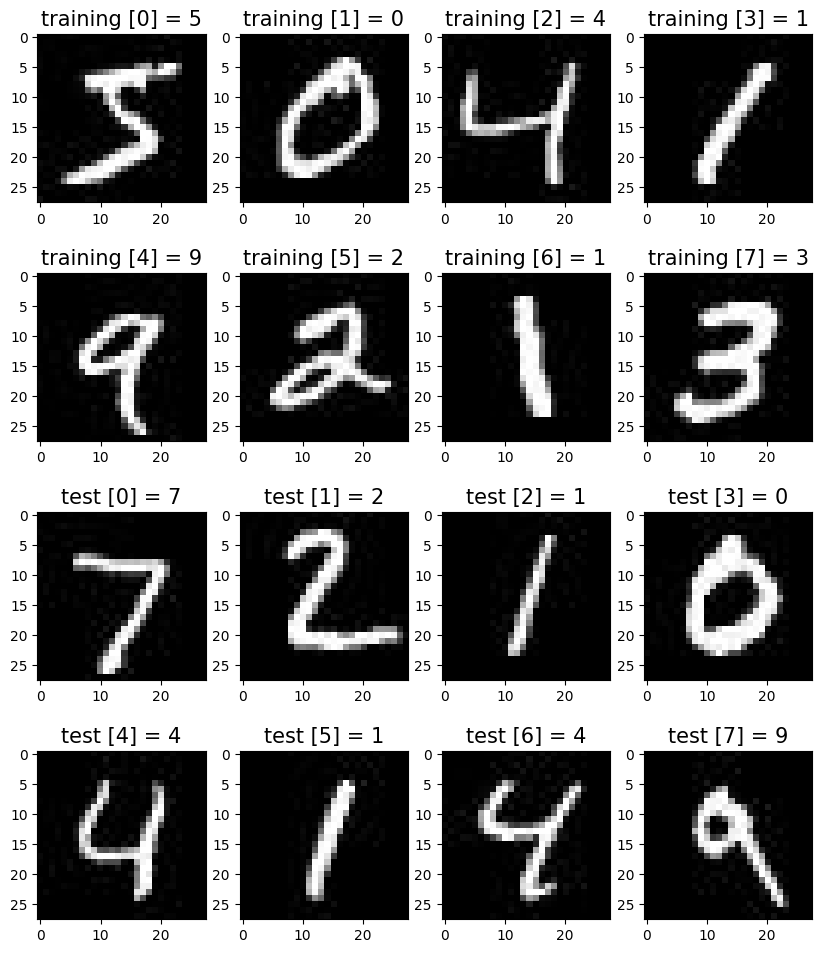

In [11]:
def show_images(images, title_texts):
    cols = 4
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(10,15))
    index = 1
    for x in zip(images, title_texts):
        image = x[0]
        title_text = x[1]
        plt.subplot(rows, cols, index)
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);
        index += 1

#
# Show some random training and test images
#
images_2_show = []
titles_2_show = []
for i in range(0, 8):
    images_2_show.append(x_train[i].reshape((28,28)))
    titles_2_show.append('training [' + str(i) + '] = ' + str(y_train[i].item()))

for i in range(0, 8):
    images_2_show.append(x_test[i].reshape((28,28)))
    titles_2_show.append('test [' + str(i) + '] = ' + str(y_test[i].item()))

show_images(images_2_show, titles_2_show)

# 학습된 모델로 예측

In [12]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(x):
    if x.ndim == 2:
        x = x.T
        x = x - np.max(x, axis=0)
        y = np.exp(x) / np.sum(np.exp(x), axis=0)
        return y.T

    x = x - np.max(x) # 오버플로 대책
    return np.exp(x) / np.sum(np.exp(x))


아래에서 sample_weight.pkl 파일을 다운받고 colab에 업로드


https://github.com/jhahncs/Class-Artificial-Intelligence/tree/Fall-2026/ch03

In [13]:
import sys, os
import numpy as np
import pickle


def init_network():
    with open("sample_weight.pkl", 'rb') as f:
        network = pickle.load(f)
    return network

def predict(network, x):
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']

    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = softmax(a3)

    return y


network = init_network()

In [19]:
print(y_test)

[7 2 1 ... 4 5 6]


In [14]:
print_image(x_test[0].reshape((28,28)))

0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.02,0.02,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,

0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,

0.00,0.00,0.00,0.02,0.04,0.02,0.01,0.02,0.02,0.02,0.01,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,

0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.01,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,

0.00,0.02,0.03,0.00,0.00,0.00,0.03,0.03,0.03,0.02,0.00,0.00,0.00,0.01,0.01,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,

0.00,0.00,0.00,0.00,0.02,0.04,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,

0.04,0.00,0.00,0.00,0.00,0.00,0.00,0.03,0.04,0.02,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,

0.00,0

In [32]:
img_index = 3
x, y = x_test[img_index], y_test[img_index]


output_values = predict(network, x)
print(output_values)
pred_class = np.argmax(output_values) # 확률이 가장 높은 원소의 인덱스를 얻는다.
print(pred_class)
print(y)

[9.9380845e-01 8.9119098e-08 1.7428503e-03 2.0255426e-04 4.9977421e-06
 3.4571190e-03 4.5993371e-04 2.2179143e-04 5.6654011e-05 4.5539495e-05]
0
0


In [33]:
accuracy_cnt = 0
for i in range(len(x_test)):
    output_values = predict(network, x_test[i])
    pred_class= np.argmax(output_values) # 확률이 가장 높은 원소의 인덱스를 얻는다.
    if pred_class == y_test[i]:
        accuracy_cnt += 1

print("Accuracy:" + str(float(accuracy_cnt) / len(x_test)))

Accuracy:0.9355


# 모델 예측 결과 시각화

In [34]:
def plot_image(predictions_array, true_label, img):
  #predictions_array, true_label, img = predictions_array[i], true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  #plt.imshow(img, cmap=plt.cm.binary)
  plt.imshow(img.reshape(28, 28), cmap='Greys')

  predicted_label = np.argmax(predictions_array)
  #print(predicted_label,true_label,np.max(predictions_array),np.sum(predictions_array))
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("pred={}({:2.0f}%), real={}".format(predicted_label,
                                100*np.max(predictions_array),
                                true_label),
                                color=color)


In [35]:
def plot_value_array(predictions_array, true_label):
  #predictions_array, true_label = predictions_array[i], true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  #plt.yticks([i/10 for i in range(0,11,1)])
  #plt.ylabel('probability')
  #plt.xlabel('class')
  #plt.title('probability')
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')


[3.4424742e-03 4.6022356e-04 6.6654854e-02 9.1660250e-04 5.5198865e-03
 1.0448541e-02 8.9779955e-01 2.4521871e-05 1.4690843e-02 4.2632961e-05]


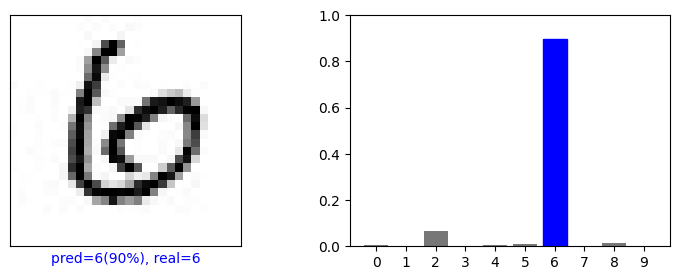

In [39]:

img_index = 11


predictions = predict(network, x_test[img_index])
print(predictions)
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.subplots_adjust(right=1.3)

plot_image(predictions, y_test[img_index], x_test[img_index].reshape((28,28)))
plt.subplot(1,2,2)
plot_value_array(predictions,  y_test[img_index])
plt.show()


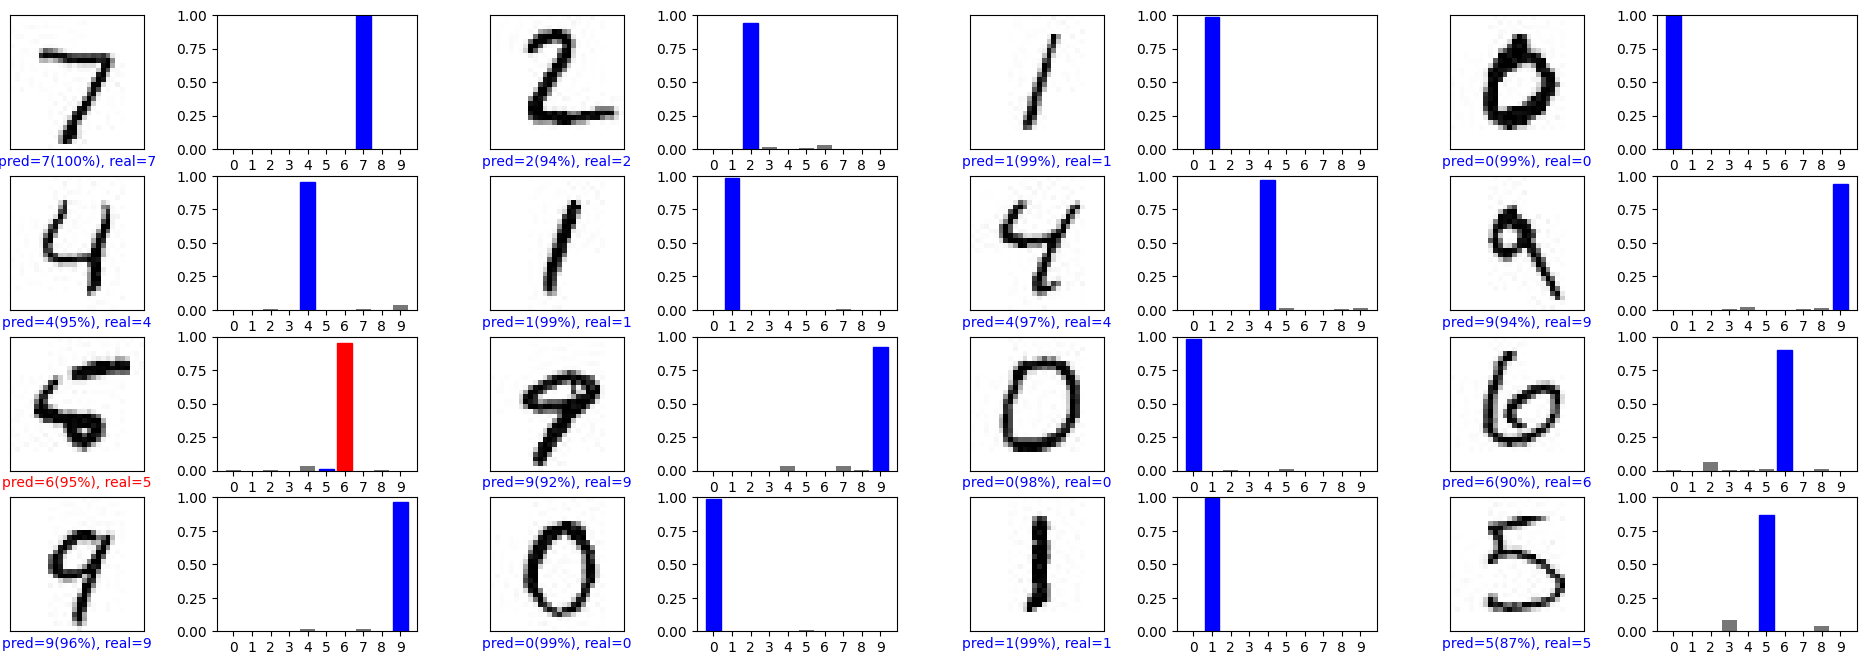

In [40]:
num_rows = 4
num_cols = 4
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))

for i in range(16):
  img = x_test[i]
  label = y_test[i]
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  predictions = predict(network, img)
  plot_image(predictions, label, img)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plt.subplots_adjust(right=1.3)
  plot_value_array(predictions, label)
plt.show()


# 그림판으로 만든 이미지 식별

In [42]:
user_img_file_name = '/content/1.jpg'

In [43]:
def print_image(sample_image):
  for r in range(0,28):
    for c in range(0,28):
      print("%.2f,"%(sample_image[r,c]),end="")
    print("\n")

user_image = io.imread(user_img_file_name,as_gray=True)
user_image = 1.0-np.array(user_image).astype(np.float32)
print(user_image.shape)
print_image(user_image)
np.savetxt(fname="user_image.csv", delimiter=",", X=user_image)

(28, 28)
0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,

0.00,0.00,0.00,0.01,0.00,0.01,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,

0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.01,0.00,0.00,0.00,0.00,

0.00,0.00,0.00,0.00,0.01,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,

0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,

0.00,0.00,0.02,0.00,0.02,1.00,0.99,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.01,0.02,0.00,0.01,0.01,0.00,0.02,0.00,0.00,0.00,0.00,

0.00,0.02,0.00,0.02,0.00,0.00,1.00,0.99,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.99,0.00,0.02,0.00,0.00,0.02,0.00,0.00,0.00,0.00,0.00

Text(0.5, 1.0, '/content/1.jpg')

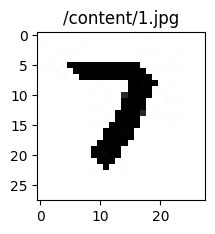

In [44]:
plt.subplot(223)
plt.imshow(user_image, vmin= 0, vmax=1, cmap='Greys')
plt.title(user_img_file_name)


In [47]:
# 왜 예측이 잘 안 될까?

print(user_image.shape)
predictions = predict(network, user_image.reshape(784))
print(predictions)
print(np.argmax(predictions))

predictions = predict(network, x_test[0])
print(predictions)
print(np.argmax(predictions))
print(y_test[0])

(28, 28)
[1.6182476e-06 1.8524024e-01 6.5826142e-01 1.2007528e-01 2.1947099e-05
 1.0378486e-04 2.5965946e-05 2.0053409e-02 1.5410056e-02 8.0626260e-04]
2
[1.08859684e-04 3.17800004e-06 9.06553934e-04 1.49731408e-03
 1.39955603e-06 5.80367450e-05 2.34653701e-08 9.96488452e-01
 1.31581683e-05 9.23127693e-04]
7
7


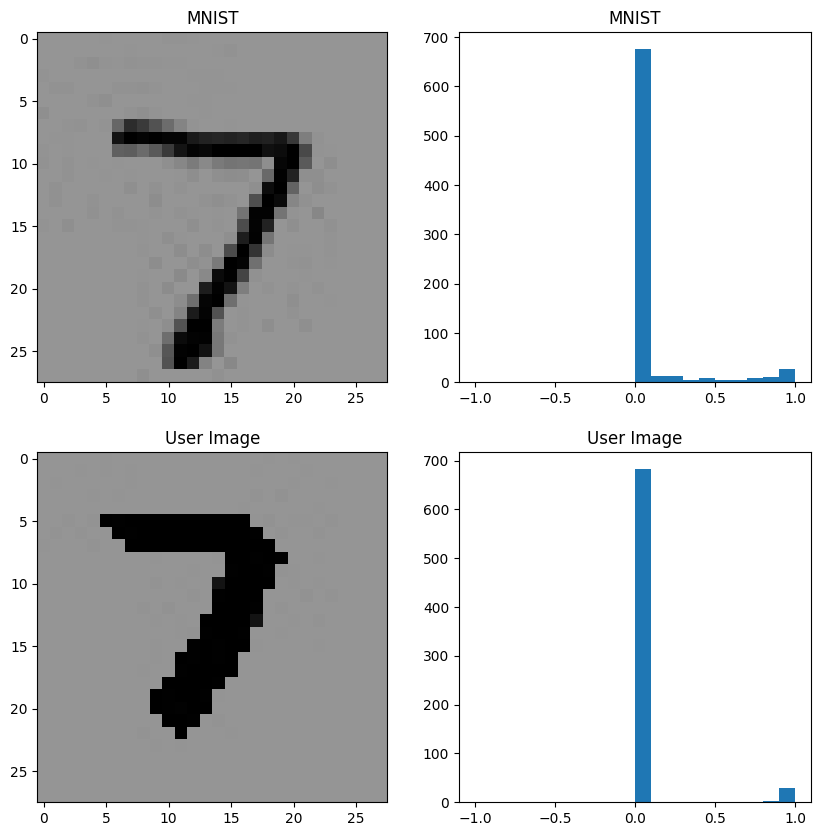

In [48]:
mnist_img = x_test[0]

plt.figure(figsize=(10,10))
plt.subplot(221)
plt.imshow(mnist_img.reshape(28,28), vmin=-1, vmax=1, cmap='Greys')
plt.title("MNIST")


plt.subplot(222)
plt.hist(mnist_img, bins=np.arange(-1, 1.1, 0.1))
plt.title("MNIST")

plt.subplot(223)
plt.imshow(user_image, vmin= -1, vmax=1, cmap='Greys')
plt.title("User Image")



plt.subplot(224)
plt.hist(user_image.flatten(), bins=np.arange(-1, 1.1, 0.1))
plt.title("User Image")
plt.show()


# 배치 처리

In [49]:
W1, W2, W3 = network['W1'], network['W2'], network['W3']

In [50]:
print(x.shape)

(784,)


In [65]:
print(x[0].shape)

(3,)


In [66]:
print(W1.shape)

(784, 50)


In [67]:
print(W2.shape)

(50, 100)


In [68]:
print(W3.shape)

(100, 10)


순차처리와 배치처리의 수행시간을 비교해보자

In [69]:
import time # time 라이브러리 import
start = time.time() # 시작

# no batch
accuracy_cnt = 0
for i in range(len(x_test)):
    output_values = predict(network, x_test[i])
    pred_class= np.argmax(output_values) # 확률이 가장 높은 원소의 인덱스를 얻는다.
    if pred_class == y_test[i]:
        accuracy_cnt += 1

print("Accuracy:" + str(float(accuracy_cnt) / len(x_test)))
print(f"{time.time()-start:.4f} sec") # 종료와 함께 수행시간 출력


Accuracy:0.9355
0.4248 sec


In [56]:
# batch
start = time.time() # 시작
batch_size = 100
accuracy_cnt = 0
for i in range(0, len(x_test), batch_size):
  x_batch = x_test[i:i+batch_size]
  y_batch = predict(network, x_batch)
  output_values = np.argmax(y_batch, axis = 1)
  accuracy_cnt += np.sum(output_values == y_test[i:i+batch_size])

print("Accuracy:" + str(float(accuracy_cnt) / len(x_test)))
print(f"{time.time()-start:.4f} sec") # 종료와 함께 수행시간 출력


Accuracy:0.9355
0.0564 sec


In [57]:
x = np.array([[0.1, 0.8, 0.1], [0.3,0.1,0.6], [0.2,0.5,0.3], [0.8,0.1,0.1]])

In [58]:
print(x)

[[0.1 0.8 0.1]
 [0.3 0.1 0.6]
 [0.2 0.5 0.3]
 [0.8 0.1 0.1]]


In [59]:
print(x.shape)

(4, 3)


In [60]:
y = np.argmax(x, axis = 1)
print(y)

[1 2 1 0]


In [61]:
y = np.array([1, 2, 1, 0])
t = np.array([1, 2, 0, 0])
print(y==t)

[ True  True False  True]


In [62]:
print(np.sum(y==t))

3


In [63]:
print(list(range(0, 10)))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [64]:
print(list(range(0, 10, 3)))

[0, 3, 6, 9]
